## Variasjoner i temperatur.

In [1]:
# Her importeres modulen pandas som pd

import pandas as pd

In [2]:
# Vi importerer numpy til bruk senere
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Her importeres funksjonaliteten datetime fra modulen datetime.
# Datetime gir oss en bekvem måte å jobbe med tidsdate på.

from datetime import datetime, timedelta

In [4]:
# Sett tidsperioden vi vil hente data fra
# Data for fremtiden kan ikke lastes inn, så når vi ber om å laste inn data får vi data helt opp til i dag.

start = datetime(1973, 1, 1)
end = datetime.today()

Vi leser inn **temperaturene og regresjonslinjen fra [notisboken om regresjon av temperaturer](Regresjon_temperaturer.ipynb).**

In [5]:
time_temperaturer_ffill = pd.read_csv('time_temperaturer.csv', index_col=0, parse_dates=True)['temp'].resample('h').ffill()
y = time_temperaturer_ffill.values.astype(float)[:, None]


In [6]:
t = (np.array(time_temperaturer_ffill.index) - np.array(time_temperaturer_ffill.index)[0]).astype(np.timedelta64(1, 'h')).astype(float)[:, None]

In [7]:
# Hjelpestørrelser for analytisk beregning av av regresjonslinje

Ey = np.mean(y)
Eyt = np.mean(y * t)
Et = np.mean(t)
Ett = np.mean(t * t)

Husk: $x_1 = \frac{E(\mathbf{y}\mathbf{t}) - E(\mathbf{t})E(\mathbf{y})}{E(\mathbf{t}^2) - E(\mathbf{t})^2}$
og $x_2 = E(\mathbf{y}) - x_1E(\mathbf{t})$

In [8]:
# Beregner heldning og hvor regresjonslinje krysser y-aksen
x1 = (Eyt - Et * Ey)/(Ett - Et * Et)
x2 = Ey - x1 * Et

# Legger x1 og x2 inn i en vektor
xx = np.array([[x1],[x2]])

# Beregner regresjonslinjen
L= x1 * t + x2

Ser vi litt nøyere på våre data finner vi ut at temperaturen svinger i løpet av ett år.

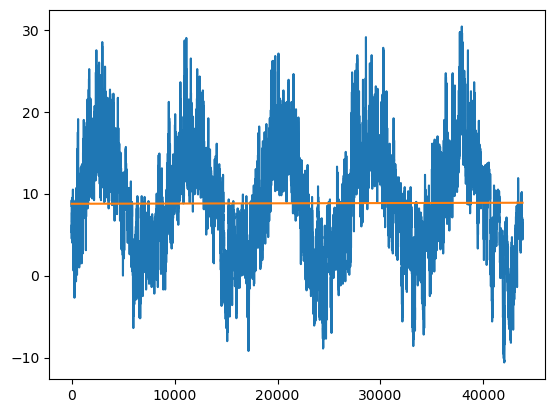

In [9]:
# Plotter daglige temperaturer og regresjonslinjen for seneste fem år mot tid
antall_timer = 5 * 365 * 24
plt.plot(y[-antall_timer:])
plt.plot(L[-antall_timer:])
#data.loc[end - timedelta(weeks=500): end].plot(y=['tavg', 'L'])

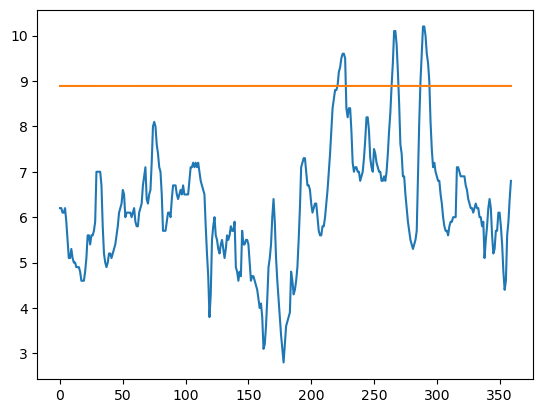

In [10]:
# Plotter daglige temperaturer og regresjonslinjen for seneste 15 dager mot tid
antall_timer = 15 * 24
plt.plot(y[-antall_timer:])
plt.plot(L[-antall_timer:])
#data.loc[end - timedelta(weeks=500): end].plot(y=['tavg', 'L'])

Vi kan prøve å ta med årlig temperatursvingning i vår regresjon ved å legge til to kolonner i matrisen A som inneholder en sinus og en cosinus funksjon med periode ett år. La oss kalle matrisen vi får på denne måten B:

In [11]:
B = np.hstack([t, np.ones_like(t), np.sin((2 * np.pi * t) / (24 * 365.2425)), np.cos((2 * np.pi * t) / (24 * 365.2425))])

På samme måten som vi fant koeffisienter for konstant- og lineært bidrag kan vi finne koeffisienter for de periodiske bidragene også:

In [12]:
xxx = np.linalg.solve(B.T @ B, B.T @ y)

Vi finner fire koeffisienter:

In [13]:
xxx

array([[ 2.98303475e-06],
       [ 7.55328279e+00],
       [-2.54524761e+00],
       [-6.34018388e+00]])

I sted fant vi to koeffisienter. Bemerk at koefisientene for konstant- og lineærdel er nesten de samme i begge sett av koeffisienter:

In [14]:
xx

array([[2.85752369e-06],
       [7.55751627e+00]])

In [15]:
årlig_forutsigelse = B @ xxx

In [16]:
trend = B[:, :2] @ xxx[:2]

Vi plotter den årlige forutsigelsen.

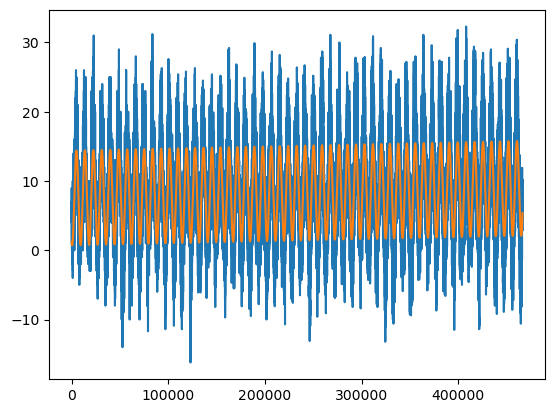

In [17]:
plt.plot(y)
# plt.plot(trend)
plt.plot(årlig_forutsigelse)

For å se om vi fanger den årlige svingningen plotter vi for en kortere tidsperiode:

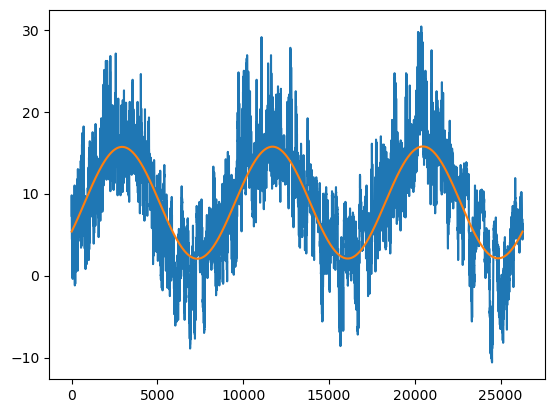

In [19]:
antall_timer = 24 * 365 * 3
plt.plot(y[-antall_timer:])
#plt.plot(trend[-antall_timer:])
plt.plot(årlig_forutsigelse[-antall_timer:])

Vi kan se hva forskjellen mellom forutsigelse og faktisk temperatur er:

In [20]:
årlig_residual = årlig_forutsigelse - y

In [50]:
np.mean(årlig_residual**2), np.sqrt(np.mean(årlig_residual**2))

(np.float64(13.3199751159735), np.float64(3.649654109086709))

Er vår forutsigelse blitt mere presis? Er kostfunksjonen minket?

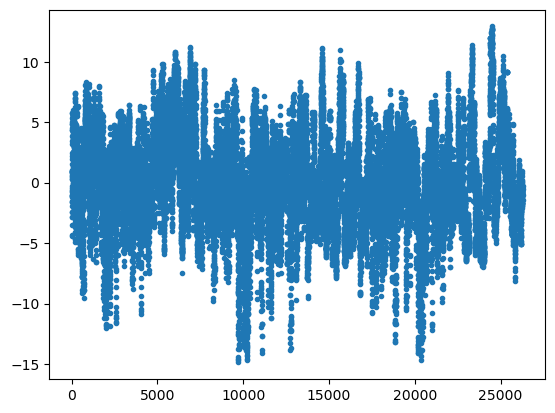

In [22]:
plt.plot(årlig_residual[-antall_timer:], '.')

Vi kan også tegne et histogram over årlig redidual og se om det passer med en normalfordeling:

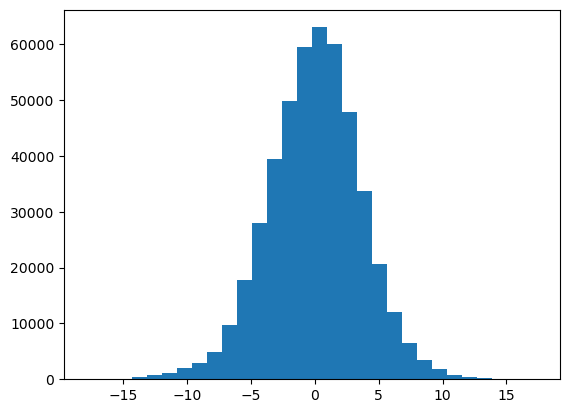

In [23]:
plt.hist(årlig_residual, bins=30);

In [24]:
from scipy.stats import norm

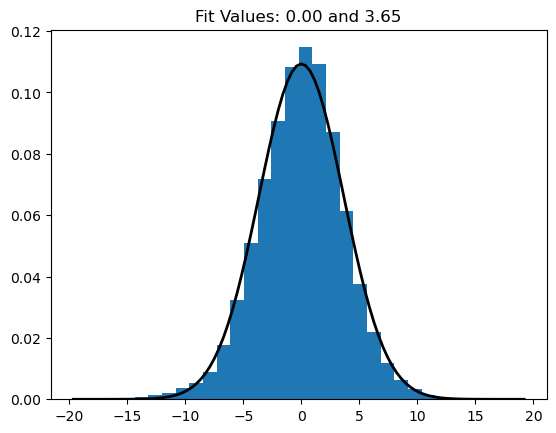

In [25]:
mu, std = norm.fit(årlig_residual)
plt.hist(årlig_residual, bins=30, density=True)
# data['årlig_residual'].plot(kind='hist', bins=30, density=True)
range = np.arange(-10, 10, 0.01)
# plt.plot(range, norm.pdf(range,0,4))
xmin, xmax = plt.xlim()
plt.plot(np.linspace(xmin, xmax, 100), norm.pdf(np.linspace(xmin, xmax, 100), mu, std), 'k', linewidth=2)
title = "Fit Values: {:.2f} and {:.2f}".format(mu, std)
plt.title(title);

Vi kan gjøre det samme for feilen til den lineære regresjon:

In [26]:
lineært_residual = L - y

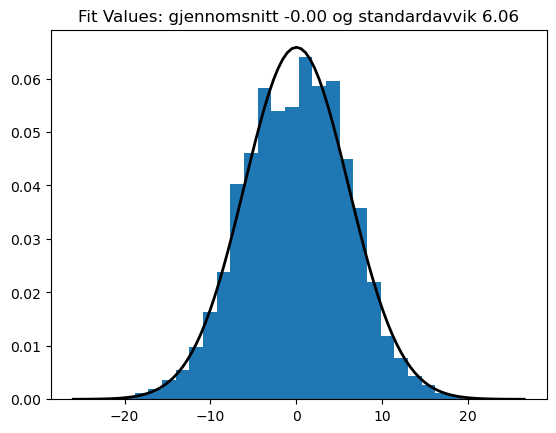

In [39]:
mu, std = norm.fit(lineært_residual)
plt.hist(lineært_residual, bins=30, density=True)
range = np.arange(-10, 10, 0.01)
# plt.plot(range, norm.pdf(range,0,4))
xmin, xmax = plt.xlim()
plt.plot(np.linspace(xmin, xmax, 100), norm.pdf(np.linspace(xmin, xmax, 100), mu, std), 'k', linewidth=2)
title = "Fit Values: gjennomsnitt {:.2f} og standardavvik {:.2f}".format(mu, std)
plt.title(title);

Vi kan også se om den periodiske svingningen vi har lagt til fanger den årlige variasjonen:

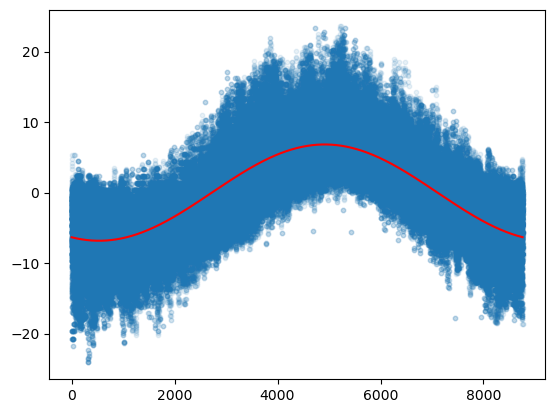

In [28]:
plt.scatter(t%(24 * 365), y - L, s=10, alpha=0.1)
plt.plot(t[:24 * 365], (årlig_forutsigelse - trend)[:24 * 365], color='red')

## Bonus

Vi vet at det også er daglig variasjon i temperaturen. Kan vi tan den med i modellen vår? 

Svar: Legg to kolonner til matrisen B for å få en ny matrise C med sinus og cosinus funksjoner med 24 timers periode.

In [29]:
C = np.hstack([
    t, 
    np.ones_like(t), 
    np.sin((2 * np.pi * t) / (24 * 365.2425)), 
    np.cos((2 * np.pi * t) / (24 * 365.2425)),
    np.sin((2 * np.pi * t) / (24)), 
    np.cos((2 * np.pi * t) / (24))
])

In [30]:
xxxx = np.linalg.solve(C.T @ C, C.T @ y)

In [31]:
xxxx

array([[ 2.98305854e-06],
       [ 7.55329832e+00],
       [-2.54522507e+00],
       [-6.34016087e+00],
       [-1.03607426e+00],
       [-1.16622946e+00]])

In [32]:
time_og_år_forutsigelse = C @ xxxx

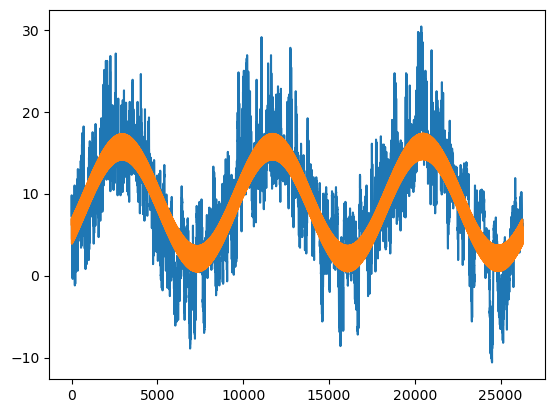

In [33]:
antall_timer = 24 * 365 * 3
plt.plot(y[-antall_timer:])
#plt.plot(trend[-antall_timer:])
plt.plot(time_og_år_forutsigelse[-antall_timer:])

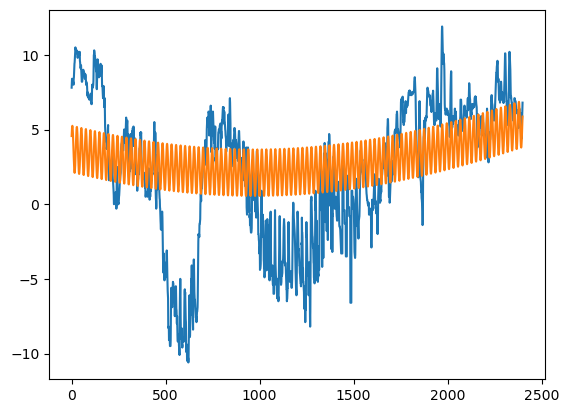

In [34]:
antall_timer = 24 * 100
plt.plot(y[-antall_timer:])
#plt.plot(trend[-antall_timer:])
plt.plot(time_og_år_forutsigelse[-antall_timer:])

In [35]:
np.mean((time_og_år_forutsigelse - y)**2)

np.float64(12.10320357531372)

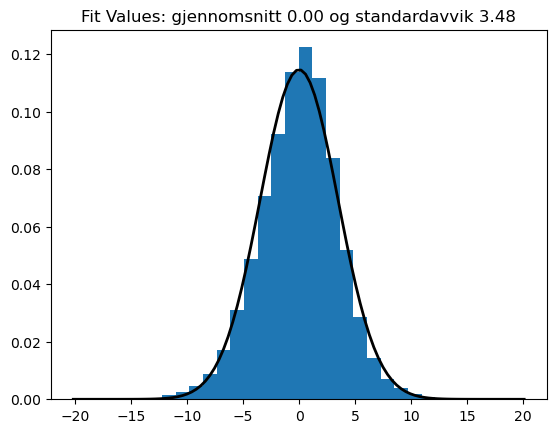

In [38]:
mu, std = norm.fit(time_og_år_forutsigelse - y)
plt.hist(time_og_år_forutsigelse - y, bins=30, density=True)
# data['årlig_residual'].plot(kind='hist', bins=30, density=True)
range = np.arange(-10, 10, 0.01)
# plt.plot(range, norm.pdf(range,0,4))
xmin, xmax = plt.xlim()
plt.plot(np.linspace(xmin, xmax, 100), norm.pdf(np.linspace(xmin, xmax, 100), mu, std), 'k', linewidth=2)
title = "Fit Values: gjennomsnitt {:.2f} og standardavvik {:.2f}".format(mu, std)
plt.title(title);

Vi kan også se om den periodiske svingningen vi nå har lagt til fanger den daglige variasjonen:

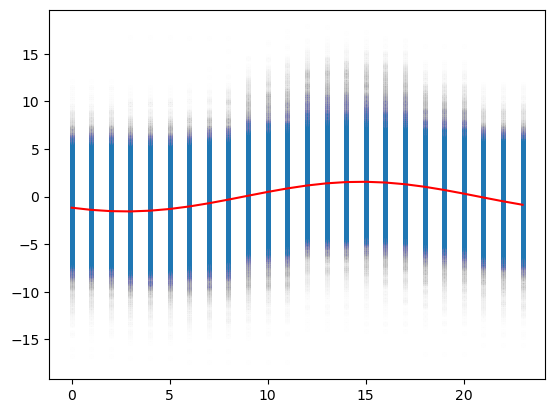

In [49]:
plt.scatter(t%(24), y - årlig_forutsigelse, s=10, alpha=0.005)
plt.plot(t[:24], (time_og_år_forutsigelse - årlig_forutsigelse)[:24], color='red')